### Rossmann Sales Time series analysis

#### Objective 
The aim of this notebook is to perform comprehensive analysis in order to identify sales trend, cyclical patterns due to holidays and stores closures and promotions impact on sales.

## EDA 
This refers to the process of scrutinizing, visualizing and summarizing a dataset so that one can make reasonable conclusions based on questions raised in observing the data. In this notebook

### Table of contents

In [ ]:
import pandas as pd 
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#uploading our dataset and reading its contents
train = pd.read_csv(r'./datas/train.csv', parse_dates=['Date'])
train.head()

C:\Users\test\AppData\Local\Temp\ipykernel_4428\2273490788.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(r'./datas/train.csv', parse_dates=['Date'])


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


The train dataset has 9 features that can be grouped into 3 segments:
* **Temporal faetures:** features like Date and Day of the week define when an event occurred and htey are useful in modelling seasonality and day based effects on sales.
* **Operational features**. These features e.g 'Open' and 'Promo' captures the operational state of the store at any particular day. Open has binary flags 1 = indicating open and 0 = closed while promo has a binary indicator of 1 or 0 showing whether a store ran a short-term promotional campaign on that date.
* **Business Target**. These are columns like Sales which is our prediction target and customers who are the key drivers for high or lower sales.

In [3]:
#train datatypes
train.dtypes

Store                     int64
DayOfWeek                 int64
Date             datetime64[ns]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday             object
SchoolHoliday             int64
dtype: object

Most of its columns are in64 datatype with outliers being dates which is a datetime and State holiday which is an object. Lets now read the contents of the store dataset.

In [4]:
store = pd.read_csv(r'./datas/store.csv')
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


The store dataset has 10 features which can be grouped into 2 groups, which are:
* **Store identity and physical attributes**. Columns like store which has a unique ID for each store, Store Type which shows various kinds of store i.e a,b,c,d and assortment which describes the level of product variety offered i.e a = basic, b = extra, c=extended.
* **Marketting environment**. Features like 'CompetitionDistance' shows the distance to  nearest competing store while 'CompetitionOpenSinceMonth / CompetitionOpenSinceYear' exhibit the approximate date and year a competitor opened shop.
* **Promotional strategy**. Columns like 'Promo2' show a binary flag of 1 f store open or 0 if its closed, 'Promo2SinceWeek / Promo2SinceYear' depicting the year or week the store started doing promotions and 'PromoInterval' which specifies the time it takes between successive promotions are done.

**Uploading the test dataset**

In [5]:
test = pd.read_csv(r'./datas/test.csv', parse_dates=['Date'])
test.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


In [6]:
store.shape

(1115, 10)

The store dataset has 1115 rows and 10 columns

In [7]:
test.shape

(41088, 8)

The test dataset has 41,088 rows and 8 columns

In [8]:
train.shape

(1017209, 9)

### Merging datasets
The store dataset has various features that will value to our training dataset in addition to the store ID which will make it possible to analyse or predict the sales of various distinct stores. We will combine the train dataset to the store one using the 'Store' column which is present on both datasets.

In [9]:
df = pd.merge(train, store, on='Store', how='inner')

In [11]:
df.shape

(1017209, 18)

This dataset is quite huge given the computation power of my laptop so I will  reduce it from having 1,017,209 rows into 6,000 rows.

In [15]:
train = df.loc[:60000, :].copy()
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [16]:
train.shape

(60001, 18)

### Checking null values 
null values in the dataset can result to biased analysis, reduceed completeness of the dataset etc thus they require careful handling to remove/modify them. We will check for null values in our dataset

In [17]:
train.isnull().sum()

Store                            0
DayOfWeek                        0
Date                             0
Sales                            0
Customers                        0
Open                             0
Promo                            0
StateHoliday                     0
SchoolHoliday                    0
StoreType                        0
Assortment                       0
CompetitionDistance            162
CompetitionOpenSinceMonth    19046
CompetitionOpenSinceYear     19046
Promo2                           0
Promo2SinceWeek              29281
Promo2SinceYear              29281
PromoInterval                29281
dtype: int64

There are 6 columns that have null values i.e PromoInterval  with 29,281, Promo2SinceWeek Promo2SinceYear both having 29,281 entries, CompetitionOpenSinceMonth and CompetitionOpenSinceYear  with 19046 while CompetitionDistance has the least null values at 162.

To remove these  null values, we will do the following:
* **CompetitionDistance**. I will assign a large value of 100km to show there isn't any competitors.
* **CompetitionOpenSinceMonth and CompetitionOpenSinceYear**. I imputted a 0 to indicate no competition so that our deep learning model will treat unknown open dates as a distinct inactive category.
* **Promo2SinceWeek & Promo2SinceYear**. filling a 0 to show the store doesn't participate in the promo2 program where a zero represents 0 weeks/years of not participating in promos.
* **PromoInterval**. setting this one none since its a categorical feature defining promotional months


In [18]:
train.loc[:,'CompetitionDistance'] = df['CompetitionDistance'].fillna(100000)
train.loc[:,'CompetitionOpenSinceMonth'] = train['CompetitionOpenSinceMonth'].fillna(0)
train.loc[:,'CompetitionOpenSinceYear'] = train['CompetitionOpenSinceYear'].fillna(0)
train.loc[:,'Promo2SinceWeek'] = train['Promo2SinceWeek'].fillna(0)
train.loc[:,'Promo2SinceYear'] = train['Promo2SinceYear'].fillna(0)
train.loc[:,'PromoInterval'] = train['PromoInterval'].fillna('None')

### Data Visualization


#### The Trend of sales through time

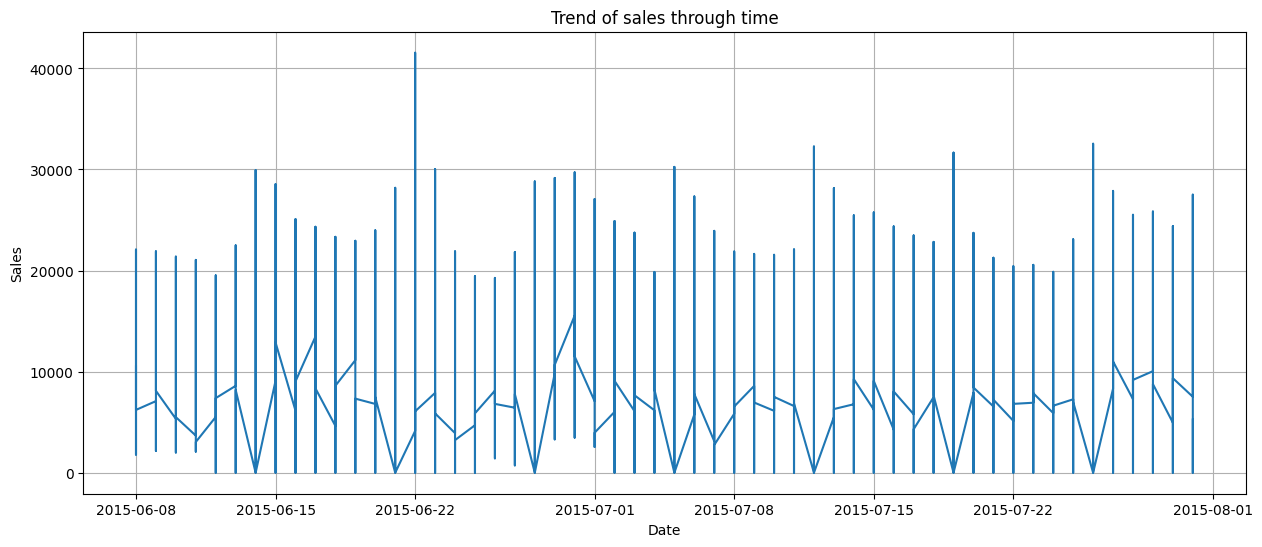

In [19]:
train = train.sort_values(by='Date')
plt.figure(figsize=(15, 6))
plt.plot(train['Date'], train['Sales'])
plt.title('Trend of sales through time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

The chart above shows  that sales drop to zero on an interval of 7 days and it rebounds sharply into temporary peaks. There is extreme spikes reaching between 30,000 and 40,000+ in gross sales. The general trend beside weekly fluctuations and temporary extreme spikes is generally horizontal within the analysed time.

##### Conclusion 
The extreme sharp peaks indicate special promotional events or major pre-holiday stockpillings. The weekly periodic sales dropping to zero are when stores are closed on sundays.

#### Distribution of sales during a week

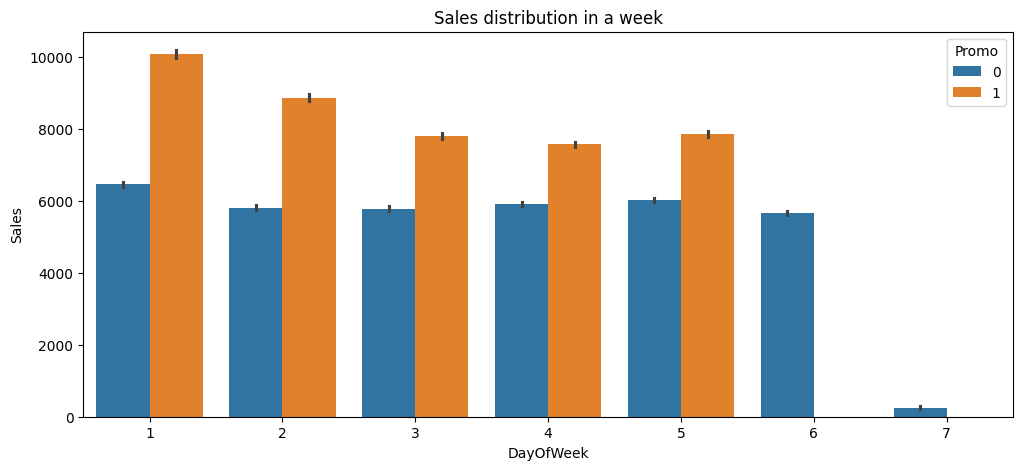

In [20]:
plt.figure(figsize=(12, 5))
sns.barplot(x='DayOfWeek', y='Sales', hue='Promo', data=train)
plt.title('Sales distribution in a week')
plt.show()

The bars shows there is higher sales in promotional days compared to when promotions aren't done with promotions  boosting massive sales ranging between 7000 - 10,000 units within 1 - 5 days while non-promotional days ranges between 5000 - 6500 . 

The peak demand is on monday recording 10,000 sales on promotional days refelecting strong early-week rebound from almost zero sales on sundays.

During day 3 - 5 sales stabilise at around 7500 - 8,000 units on promotional days but on non-promotional days are around 6,000.

#### Sales variance and customer density

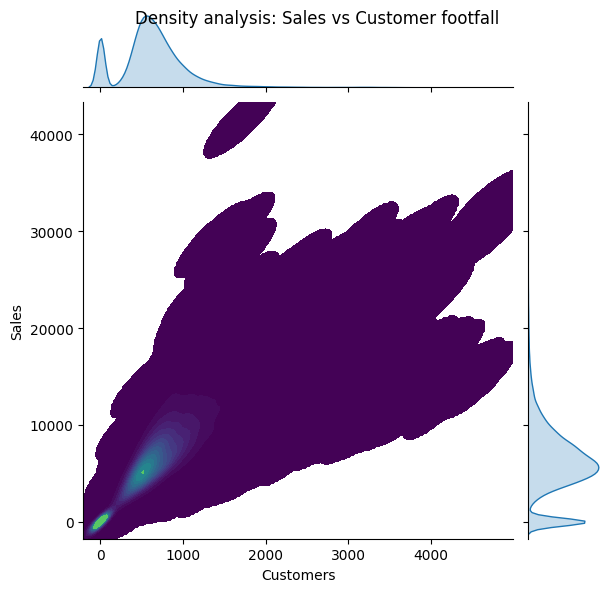

In [21]:
g = sns.jointplot(data=train, x='Customers', y='Sales', kind='kde', fill=True, cmap='viridis', thresh=0, levels=15)
g.fig.suptitle('Density analysis: Sales vs Customer footfall')
plt.show()

The observations of this plot will be categorized into 3 points:

 1. The density contour forms an elongated diagonally rising shape which indicates a strong correlation between gross sales and customer numbers.The yellow -greenish core represents the highest concentratration of daily operations tightly clustering around 500 - 1000 customers generating between 5,000 - 8,000 in sales. There is a small cluster at zero customers representing days when the stores are closed.
 2. The plot shows a fan-out-effect where the spread of our data is narrow between 300 - 700 customers where sales are tight ranging between approximately 5,000 - 12,000 while it fans-out i.e widens out significantly past 2000 customers where sales range between 12,000 and 30,000. due to variations in sales per customer.
 3. The top and right kernel density estimate(KDE) plots shows righ-skweness for both features  due to promotional events that lead to surge in sales.

#### Sales per customer during the week

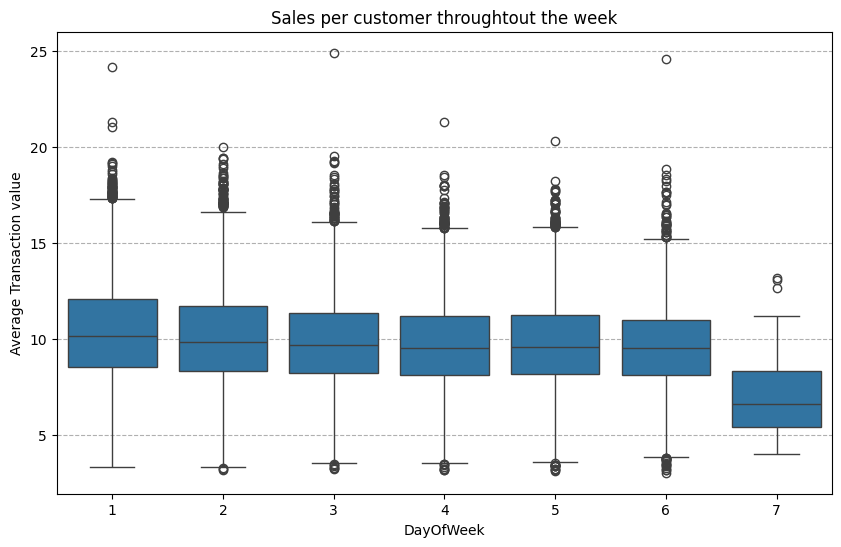

In [22]:
train['Sales_per_customer'] =  train['Sales'] / train['Customers']
active_days= train[train['Open'] == 1]
plt.figure(figsize=(10, 6))
sns.boxplot(x='DayOfWeek', y='Sales_per_customer', data=active_days)
plt.title('Sales per customer throughtout the week')
plt.ylabel('Average Transaction value')
plt.grid(axis='y', ls='--')
plt.show()

Across all operational days i.e day 1-6, the median sale per customer is almost constant at approximately 10 units with a tranactional value of around 8 - 13 units as shown by the interquantile range. There are notable outliers at 15 - 25 units driven by promotional effects bythe stores. 

On sundays, the median sale per customer is around 7 units with a transactional value of around 5.5 - 9  units with fewer outlier sales since most stores are closed  indicating a convenience store visit.



In [23]:
correlation = train['Customers'].corr(train['Sales'], method='pearson')
print(f'Perason correlation coefficient: {correlation:.4f}')


Perason correlation coefficient: 0.8630


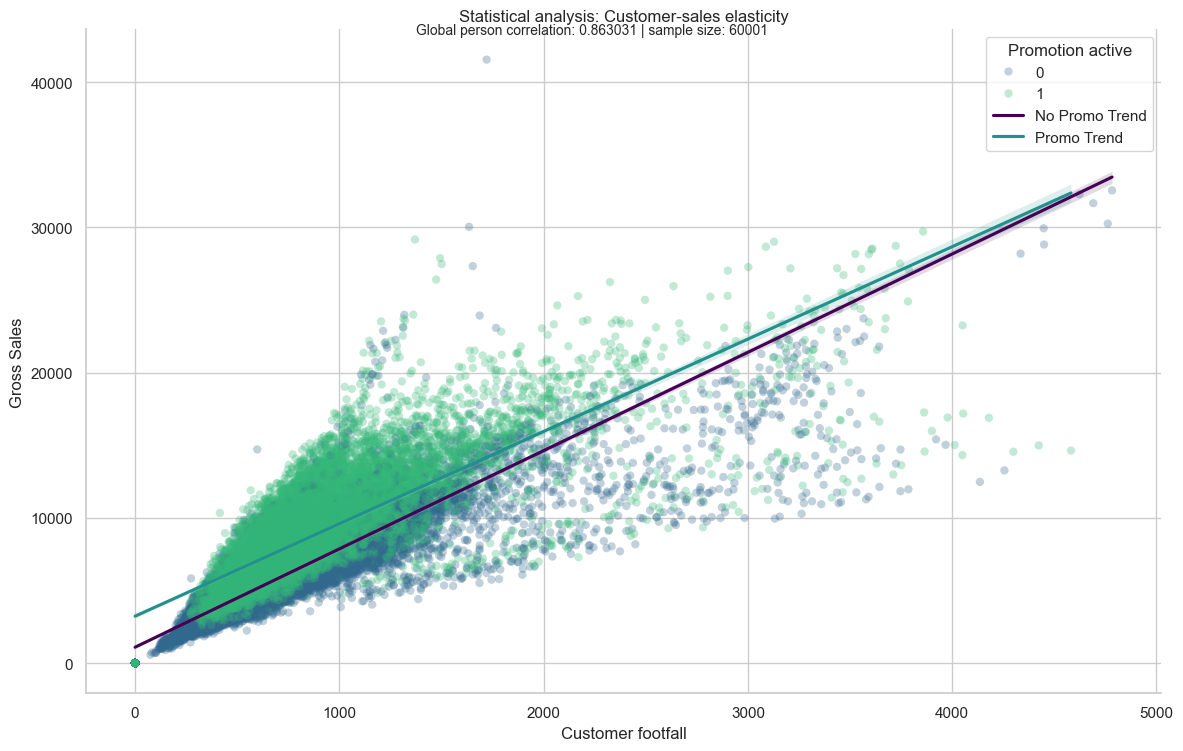

In [24]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 8))
corr_val = train['Customers'].corr(train['Sales'])
sns.scatterplot(x='Customers', y='Sales', hue='Promo', alpha=0.3, edgecolor='None', palette='viridis', data=train)
sns.regplot(data=train[train['Promo'] == 0], x='Customers', y='Sales', scatter=False, color='#440154', label='No Promo Trend')
sns.regplot(data=train[train['Promo'] == 1], x='Customers', y='Sales', scatter=False, color='#21918c',label='Promo Trend')
plt.title('Statistical analysis: Customer-sales elasticity')
plt.suptitle(f'Global person correlation: {corr_val:3f} | sample size: {len(train)}', y=0.92, fontsize=10)
plt.xlabel('Customer footfall')
plt.ylabel('Gross Sales')
plt.legend(title='Promotion active')
sns.despine()
plt.tight_layout()
plt.show()

Grosss sales and customer footfall have strong positive correlation of 86% showing linear dependency between the two confirmed with the parallel rising  regressions lines. The  promo trend regression line maintains a constant rise above no promo line connfirming that promotions consistently increase transactional values for any given customer value

There is a high density of clusters when promotions are active between 500 - 1500 customers generating between 4,000 - 17,000 sales  which over-shadows the non-ptomotional sales.

#### Average store sales given assortment

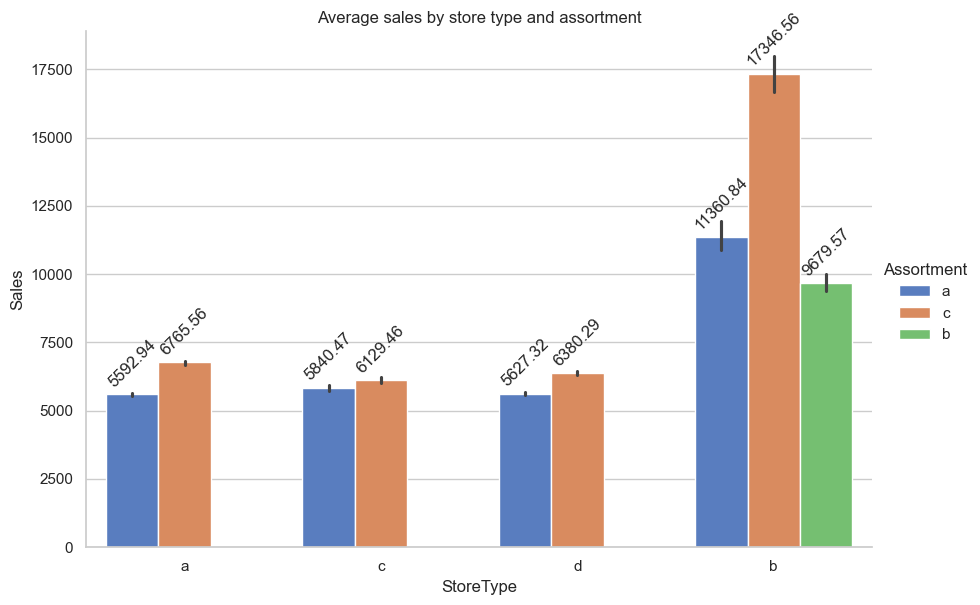

In [25]:
g = sns.catplot(x='StoreType', y='Sales', hue='Assortment', data=train, kind='bar', palette='muted', height=6, aspect=1.5)
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, rotation=45)
plt.title('Average sales by store type and assortment')
plt.show()

Store B has the highest sales in all assortments  with c having 17,346 units, seconded by a with  11,360 units and b with 9,679 units. Other stores have sales in all assortments ranging between 5592  - 5840 for assortments a and 6,129 - 6,765 for assortments c. 

Assortment b is only available to store b

On the first plot, Sales are righ-skewed with most operating days concentrating around 4,000 - 8,000 units while having a long-tail past 20,000 units which was driven by promotional surges. There is a massive vertical spike at 0 which represents store closures duriing sundays or holidays.

on plot 2, The sales are normalized by performing logarithmic transformation thus the plot shows a bell-curve centred around 9

In [ ]:

train['Month'] = train['Date'].dt.month_name()
train['Day_name'] = train['Date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November','December']
pivot_table = train.pivot_table(inde)

#### Sales velocity in relation to month given day

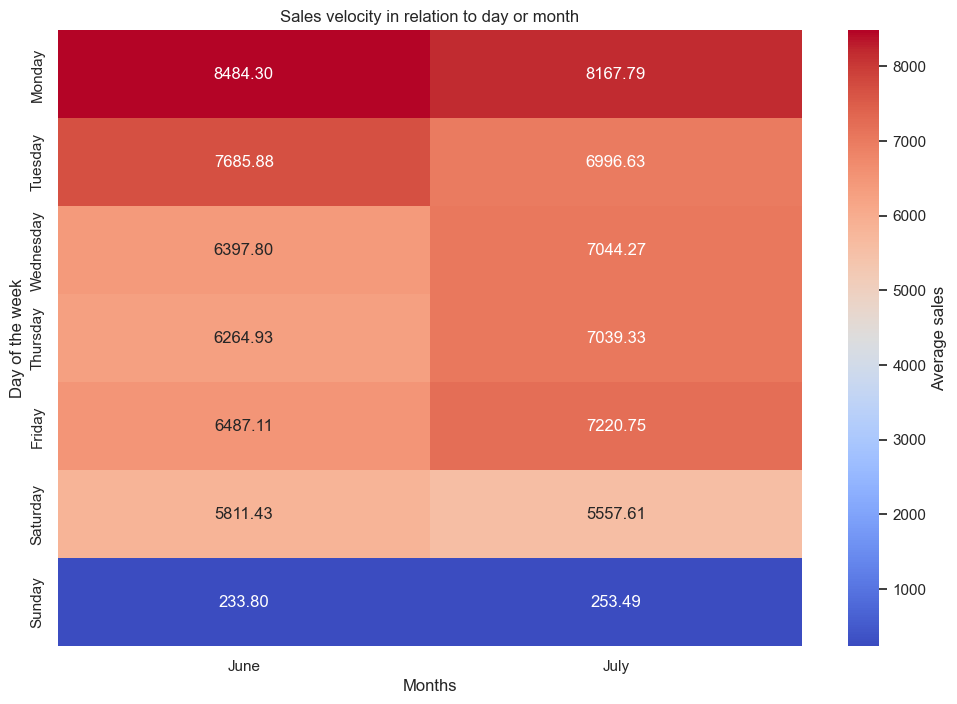

In [28]:
train['Month'] = train['Date'].dt.month_name()
train['DayName'] = train['Date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November','December']
pivot_table = train.pivot_table(index='DayName', columns='Month', values='Sales', aggfunc='mean')
pivot_table = pivot_table.reindex(index=day_order, columns=[m for m in month_order if m in pivot_table.columns])
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='coolwarm', cbar_kws={'label': 'Average sales'})
plt.title('Sales velocity in relation to day or month')
plt.xlabel('Months')
plt.ylabel('Day of the week')
plt.show()

Monday shows dominance over the other days representing sales of 8,484 in june and 8,167 units in July which porbably driven by pent-up demand due to store closures on sundays.

The mid-week varies between 5,811 - 7,685 units on June with July having a higher mid-week demand with sales between friday - Wednesday having an average of 7,000 units. Sundays have lower sales recording 233 units in June and 253 in July

#### Average transaction value beween promos and non-promos

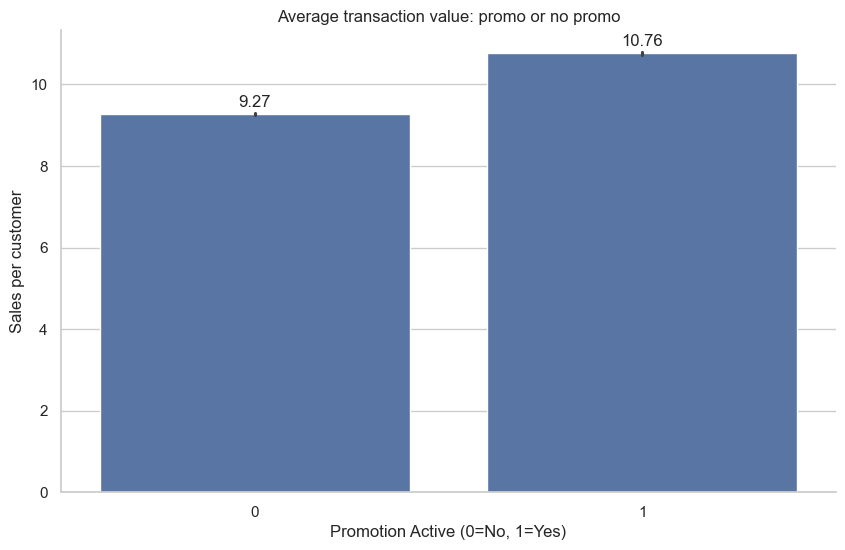

In [29]:
df_active = train[train['Open'] == 1].copy()
df_active['Sales_per_customer'] = df_active['Sales'] / df_active['Customers']
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Promo', y='Sales_per_customer',data=df_active)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.title('Average transaction value: promo or no promo')
plt.xlabel('Promotion Active (0=No, 1=Yes)')
plt.ylabel('Sales per customer')
sns.despine()
plt.show()

During promotions drives, sales surge which is shown by the bell-curve showing a   peak of around 7,000 units with a high spreads which are results of extreme revenue spikes during promotionswhile non-promotional sales have a peak at around 5, 000 units with a narrow spread.

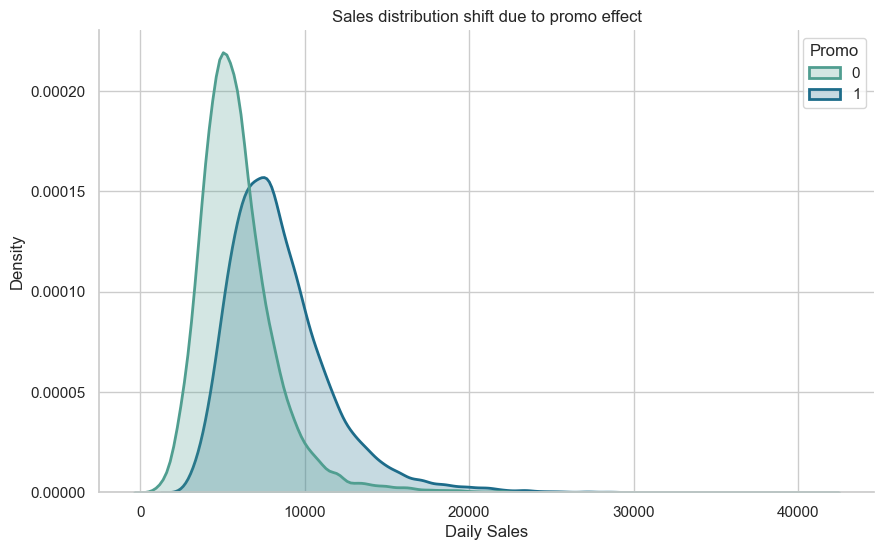

In [30]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_active, x='Sales', hue='Promo', fill=True, common_norm=False, palette='crest', linewidth=2)
plt.title('Sales distribution shift due to promo effect')
plt.xlabel('Daily Sales')
plt.ylabel('Density')
plt.annotate(f'Efficiency lift: $1.1 per customer', xy=(15000, 0.0005))
sns.despine()
plt.show()